# SolarFarmer API — PVPMC 2026 Workshop
**Bankable energy yield calculations with the SolarFarmer Python SDK (Workflow 2 — PVSystem builder)**

*Thursday 14 May 2026 · PVPMC Workshop, Albuquerque (NM)*

---

This notebook demonstrates how to design a PV plant from scratch and run an energy yield calculation
entirely via API, using the [`dnv-solarfarmer`](https://github.com/dnv-opensource/solarfarmer-python-sdk) SDK.

It follows **Workflow 2 — PVSystem builder**, which constructs the API payload from high-level
design inputs (capacity, tilt, equipment files) without needing a SolarFarmer Desktop export.

| Step | What happens |
|------|--------------|
| Weather data | Solcast TMY → SolarFarmer TSV format via `sf.from_solcast()` |
| Plant design | `PVSystem` class — location, capacity, array geometry, equipment |
| Calculation | `plant.run_energy_calculation()` → SolarFarmer API |
| Results | `CalculationResults` — KPIs, monthly energy, loss breakdown |
| Optimisation | GCR sweep (6 variants) + simple LCOE model to find the economic optimum |

**SDK documentation:** https://dnv-opensource.github.io/solarfarmer-python-sdk/  
**API documentation:** https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/WebApi/Introduction/introduction.html

---
### Before you start
1. Obtain a [SolarFarmer API key](https://solarfarmer.dnv.com/) from the SolarFarmer portal.
2. Set it as an environment variable:
   - Windows: `set SF_API_KEY=your-key`
   - Mac/Linux: `export SF_API_KEY=your-key`
3. Obtain a [Solcast API key](https://toolkit.solcast.com.au/register) for the weather data step.
4. Run each cell in order — the cells build on each other.


## 1. Setup & Configuration

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import solarfarmer as sf
from solarfarmer import PVSystem

# --- API keys ---
SF_API_KEY      = os.environ.get("SF_API_KEY",      "YOUR_SF_KEY_HERE")
SOLCAST_API_KEY = os.environ.get("SOLCAST_API_KEY", "YOUR_SOLCAST_KEY_HERE")

for name, key in [("SF_API_KEY", SF_API_KEY), ("SOLCAST_API_KEY", SOLCAST_API_KEY)]:
    status = "found" if "YOUR" not in key else "NOT SET — paste it above or export the env var"
    print(f"{name}: {status}")

SF_API_KEY: found
SOLCAST_API_KEY: found


## 2. Location

We use the **workshop venue in Albuquerque, New Mexico** — the same site as the Solcast notebook —
so that the two notebooks can be used together end-to-end.

| Parameter | Value |
|-----------|-------|
| Latitude | 35.10 °N |
| Longitude | -106.67 °E |
| Altitude | 1510 m |


In [2]:
LATITUDE  = 35.10
LONGITUDE = -106.67
ALTITUDE  = 1510      # metres above sea level

print(f"Site: {LATITUDE}°N, {LONGITUDE}°E, {ALTITUDE} m")


Site: 35.1°N, -106.67°E, 1510 m


## 3. Weather Data — Solcast TMY → SolarFarmer TSV

SolarFarmer requires a meteorological file in TSV format.
`sf.from_solcast()` handles the full conversion in one call — column renaming, unit conversion,
and TMY timestamp remapping to a single calendar year are all done automatically.

In [3]:
%%time
from solcast import tmy

TMY_PARAMETERS = ['ghi', 'dhi', 'air_temp', 'wind_speed_10m', 'precipitable_water']

tmy_data = tmy.radiation_and_weather(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    output_parameters=TMY_PARAMETERS,
    api_key=SOLCAST_API_KEY,
).to_pandas()

print(f"TMY: {len(tmy_data)} records | {tmy_data.index[0]} → {tmy_data.index[-1]}")
tmy_data.head()

TMY: 8760 records | 2059-01-01 01:00:00+00:00 → 2060-01-01 00:00:00+00:00
CPU times: total: 31.2 ms
Wall time: 7.21 s


,air_temp,dhi,ghi,precipitable_water,wind_speed_10m
period_end,,,,,
2059-01-01 01:00:00+00:00,-1.3,0,0,1.8,3.5
2059-01-01 02:00:00+00:00,-2.0,0,0,1.6,3.1
2059-01-01 03:00:00+00:00,-4.4,0,0,1.5,3.0
2059-01-01 04:00:00+00:00,-6.4,0,0,1.4,2.9
2059-01-01 05:00:00+00:00,-6.6,0,0,1.4,2.6


In [4]:
WEATHER_FILE = Path("weather_albuquerque_tmy.tsv")

# from_solcast() handles column renaming, precipitable_water unit conversion (kg/m² → cm),
# and TMY timestamp remapping to a single calendar year automatically
sf.from_solcast(df=tmy_data, output_path=WEATHER_FILE)

print(f"Weather file written: {WEATHER_FILE.resolve()}")

Weather file written: C:\repos\pvpmc_usa_2026_dnv_apis\weather_albuquerque_tmy.tsv


## 4. Plant Design — `PVSystem`

`PVSystem` constructs an approximate plant layout from high-level inputs.
String sizing, inverter count, and row geometry are inferred automatically —
ideal for early-stage screening and scenario comparison.

| Parameter | Value | Notes |
|-----------|-------|-------|
| `dc_capacity_MW` | 10 MW | DC nameplate capacity |
| `ac_capacity_MW` | 8 MW | AC capacity |
| `grid_limit_MW` | 8.5 MW | Grid export limit |
| `mounting` | `Tracker` | Single-axis tracker |
| `tilt` | 60° | Maximum rotation angle for tracker |
| `azimuth` | 180° | South-facing rotation axis |
| `gcr` | 0.40 | Ground coverage ratio (initial; swept later) |
| `bifacial` | `True` | Bifacial modules enabled |
| `soiling_loss` | monthly | Estimated monthly losses (per-unit) |
| `albedo` | 0.20 | Monthly uniform ground reflectance |


In [5]:
plant = PVSystem(
    name="Albuquerque 10 MW — Workshop",
    latitude=LATITUDE,
    longitude=LONGITUDE,
    altitude=ALTITUDE,
)

# --- Capacity ---
plant.dc_capacity_MW = 10.0
plant.ac_capacity_MW = 8.0
plant.grid_limit_MW  = 8.5

# --- Array configuration ---
plant.mounting  = sf.MountingType.TRACKER   # single-axis tracker
plant.tilt      = 60.0                      # max rotation angle
plant.azimuth   = 180.0                     # south-facing axis
plant.gcr       = 0.40
plant.bifacial  = True

# --- Inverter ---
plant.inverter_type      = sf.InverterType.CENTRAL
plant.transformer_stages = 1

# --- Soiling (monthly, per-unit) — from Solcast soiling API, SRC API, or other estimate ---
plant.soiling_loss = [0.04, 0.04, 0.03, 0.02, 0.02, 0.01,
                      0.01, 0.02, 0.02, 0.03, 0.04, 0.04]

# --- Albedo (monthly, per-unit) — from Solcast TMY, SRC API or other estimate ---
plant.albedo = [0.20] * 12

# --- Weather file (converted from Solcast TMY above) ---
plant.weather_file = WEATHER_FILE

print("PVSystem configured.")


PVSystem configured.


## 5. Equipment Files — PAN & OND

SolarFarmer uses industry-standard **PAN** (module) and **OND** (inverter) files from PVsyst.
Register them with `add_pan_files()` and `add_ond_files()`.

The dict key is your own label; the spec ID sent to the API is derived automatically from the filename.

> **Try it:** swap in your own PAN/OND files from your equipment database or download them from
> [https://www.photovoltaik-web.de/photovoltaik/datenbanken/pvsyst-dateien](https://www.photovoltaik-web.de/photovoltaik/datenbanken/pvsyst-dateien).

In [6]:
# --- Paths to your PAN and OND files ---
# Update these paths to point to your actual equipment files
PAN_FILE = Path(r"equipment/TrinaSolar_TSM-375DE14A(II)_APP.PAN")       # module specification
OND_FILE = Path(r"equipment/60_10_APP02.OND")                           # inverter specification

if PAN_FILE.exists() and OND_FILE.exists():
    plant.add_pan_files({"My Module": PAN_FILE})
    plant.add_ond_files({"My Inverter": OND_FILE})
    print(f"Module file:   {PAN_FILE}")
    print(f"Inverter file: {OND_FILE}")
else:
    print("WARNING: Equipment files not found.")
    print(f"  Expected PAN: {PAN_FILE.resolve()}")
    print(f"  Expected OND: {OND_FILE.resolve()}")
    print("Place your .PAN and .OND files at the paths above and re-run.")

Module file:   equipment\TrinaSolar_TSM-375DE14A(II)_APP.PAN
Inverter file: equipment\60_10_APP02.OND


## 6. Review Configuration

Before submitting to the API, print a full summary of the plant configuration to catch any issues.

In [7]:
plant.describe(verbose=True)


PV PLANT SUMMARY

--- BASIC METADATA ---
Name: Albuquerque 10 MW — Workshop
Results Available: False

--- LOCATION ---
Latitude: 35.1°
Longitude: -106.67°
Altitude: 1510 m
Timezone: UTC

--- CAPACITY ---
DC Capacity: 10.0 MW
AC Capacity: 8.0 MW
Grid Limit: 8.5 MW

--- ARRAY CONFIGURATION ---
GCR (Ground Coverage Ratio): 0.4
Pitch: None m
Tilt: 60.0°
Azimuth: 180.0°

--- MOUNTING & ORIENTATION ---
Mounting Type: MountingType.TRACKER
Module Orientation: OrientationType.PORTRAIT
Modules Across: 1
Mounting Height: 0.7 m
Flush Mount: False

--- BIFACIAL PARAMETERS ---
Bifacial Modules: True
  - Transmission Factor: 0.0
  - Shade Loss Factor: 0.0
  - Mismatch Loss Factor: 0.0

--- INVERTER & TRANSFORMER ---
Inverter Type: InverterType.CENTRAL
String Length: None modules
Transformer Stages: 1 (0=Ideal/NoLoss, 1=MV/HV transformer)

--- LOSSES ---
DC Ohmic Loss: 0.015 (per unit)
AC Ohmic Loss: 0.005 (per unit)
Module Mismatch Loss: 0.005 (per unit)
Module Quality Factor: 0.0 (per unit)
LID Los

## 7. Run Energy Calculation

A single call to `run_energy_calculation()` handles everything:

1. Converts the `PVSystem` spec to the API JSON payload
2. Infers string length and inverter count from the PAN/OND files
3. Submits to the SolarFarmer `ModelChain` endpoint
4. Polls for results and returns a `CalculationResults` object

Results are also stored in `plant.results` for later access.

In [7]:
%%time
results = plant.run_energy_calculation(
    project_id="workshop-albuquerque-10mw",
    api_key=SF_API_KEY,
    print_summary=True,
    save_outputs=True,
    outputs_folder_path="sf_outputs",
)


DESIGN SUMMARY

Capacity Summary:
  Target (input) DC Capacity: 10.0 MW
  Design (output for simulation) DC Capacity: 9.996 MW
  Target (input) AC Capacity: 8.0 MW
  Design (output for simulation) AC Capacity: 8.040 MW

Layout Configuration:
  Number of Inverters: 134
  Number of Modules: 26666
  String Length: 15
  Total Strings: 2010

-------------------------------------------------------
		General site data:
-------------------------------------------------------
Project name = workshop-albuquerque-10mw
Location (latitude, longitude, altitude) = 35.10000°, -106.67000°, 1510.0 m
2D/3D = 2D calculation
Mounting type = Single-axis trackers
AC capacity of system = 8.04 MW
DC capacity of system = 9.995625 MW
Run in SolarFarmer API version 6.1.0
-------------------------------------------------------
    Annual Performance Summary (project year 1, 2059)
-------------------------------------  -----------------
Average annual temperature             13.92°C
Horizontal irradiation         

## 8. Key Performance Indicators

Quick access to the Year 1 headline metrics, plus a look at what was actually built
(the design may differ slightly from the target capacity as string sizing is rounded).

In [8]:
# --- Year 1 performance metrics ---
perf = results.get_performance(project_year=1)

print("Year 1 Performance")
print("-" * 50)
print(f"  Net energy:          {perf['net_energy']:.1f} MWh/year")
print(f"  Specific yield:      {perf['energy_yield']:.1f} kWh/kWp")
print(f"  Performance ratio:   {perf['performance_ratio']:.3f}")
print(f"  GHI:                 {perf['horizontal_irradiation']:.1f} kWh/m²")
print(f"  In-plane irradiance: {perf['irradiation_on_tilted_plane']:.1f} kWh/m²")

# --- Design summary (target vs. actual capacities) ---
print("\nDesign Summary")
print("-" * 50)
ds = plant.design_summary
print(f"  Target DC / AC:  {ds['target_dc_capacity_MW']:.2f} MW / {ds['target_ac_capacity_MW']:.2f} MW")
print(f"  Design DC / AC:  {ds['design_dc_capacity_MW']:.2f} MW / {ds['design_ac_capacity_MW']:.2f} MW")
print(f"  Inverters:       {ds['number_inverters']}")
print(f"  Modules:         {ds['number_modules']:,}")
print(f"  String length:   {ds['string_length']} modules")

Year 1 Performance
--------------------------------------------------
  Net energy:          21704.7 MWh/year
  Specific yield:      2171.4 kWh/kWp
  Performance ratio:   0.792
  GHI:                 2041.1 kWh/m²
  In-plane irradiance: 2740.6 kWh/m²

Design Summary
--------------------------------------------------
  Target DC / AC:  10.00 MW / 8.00 MW
  Design DC / AC:  10.00 MW / 8.04 MW
  Inverters:       134.0
  Modules:         26,666.0
  String length:   15 modules


## 9. Monthly Energy Profile

The monthly breakdown reveals seasonal patterns — useful for checking that
tracker tilt and soiling inputs are reasonable.

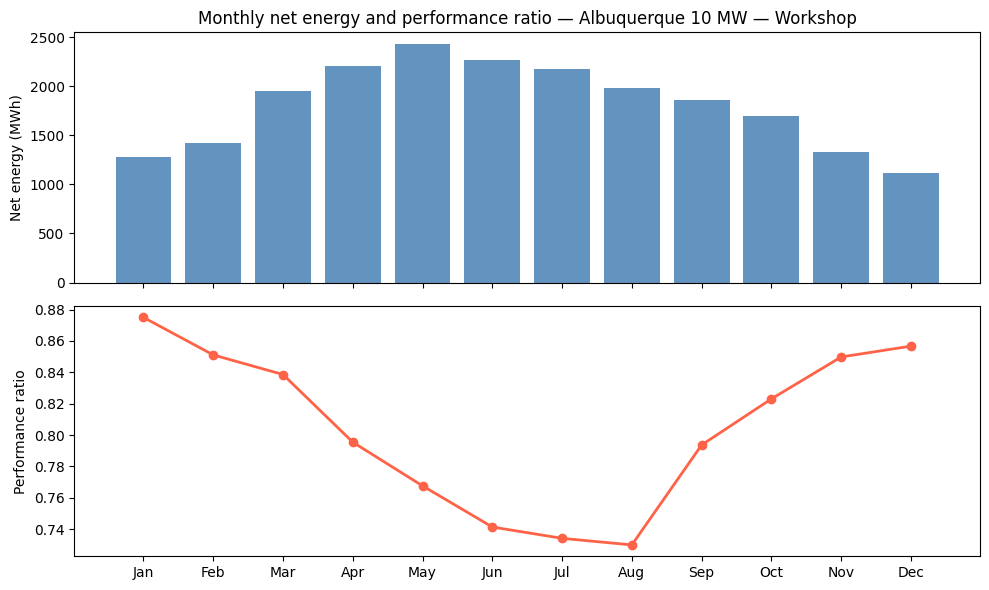


Annual net energy: 21704.7 MWh


In [9]:
monthly_raw = results.get_monthly_results_table(include_energy_results=True, include_effects=False)
monthly_df  = pd.DataFrame(monthly_raw['energy_results'])

# Filter to project year 1 and sort by calendar month
monthly_y1 = monthly_df[monthly_df['project_year'] == 1].copy()
monthly_y1 = monthly_y1.sort_values('month').reset_index(drop=True)

MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.bar(MONTH_LABELS, monthly_y1['net_energy'], color='steelblue', alpha=0.85)
ax1.set_ylabel('Net energy (MWh)')
ax1.set_ylim(bottom=0)
ax1.set_title(f"Monthly net energy and performance ratio — {plant.name}")

ax2.plot(MONTH_LABELS, monthly_y1['performance_ratio'], 'o-',
         color='tomato', linewidth=2)
ax2.set_ylabel('Performance ratio')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

print(f"\nAnnual net energy: {monthly_y1['net_energy'].sum():.1f} MWh")


## 10. Annual Loss Summary

The annual effects table lists all modelled losses and gains — the key deliverable
in a bankable energy yield assessment. The first cell prints a formatted table;
the second renders a horizontal waterfall-style bar chart for quick visual review.


In [10]:
# Print the formatted annual results table (energy yield + all effects)
results.print_annual_results(show_energy_results=True, show_effects=True)

----------------------------------------
Annual Results Summary (Years: 1 (2059))
----------------------------------------
Property                     Units          Year 1
                                            (2059)
---------------------------  --------  -----------
Energy yield                 kWh/kWp       2171.42
Net energy                   MWh/year      21704.7
Production DC                kWh       2.33303e+07
Production AC                kWh       2.20263e+07
Performance Ratio            %               79.23
Performance Ratio Bifacial   %               79.23
Average annual temperature   °C              13.92
Horizontal irradiation       kWh/m²        2041.11
Irradiation on tilted plane  kWh/m²        2740.61
GI with horizon              kWh/m²        2740.61
Global effective irradiance  kWh/m²        2593.26
Gain on tilted plane         %               34.27
----------------------------------------
Annual Effects Summary (Years: 1 (2059))
------------------------------

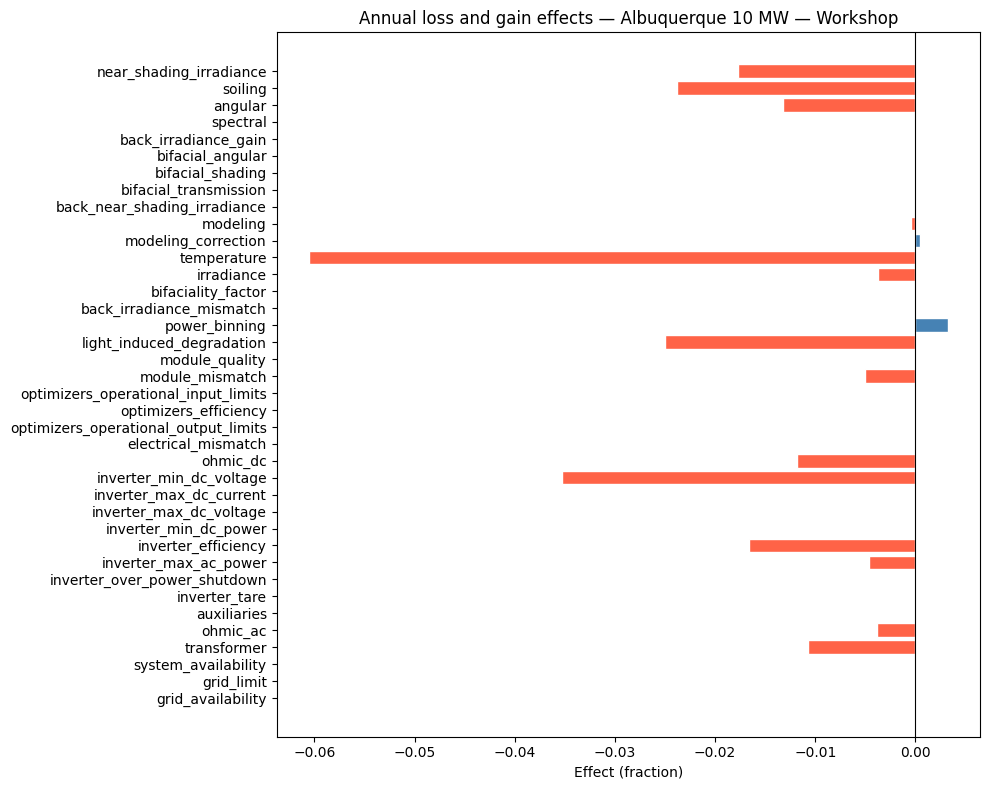

In [11]:
# Waterfall-style bar chart of the top loss/gain effects
annual_raw = results.get_annual_results_table(include_energy_results=False, include_effects=True)
effects_df = pd.DataFrame(annual_raw['effects'])
effects_y1 = effects_df[effects_df['project_year'] == 1].copy()

# Melt from wide format (one column per effect) to long format (name/value rows)
id_cols = ['project_year', 'calendar_year', 'horizon']
effects_y1 = effects_y1.drop(columns=id_cols).melt(var_name='name', value_name='value')

colors = ['tomato' if v < 0 else 'steelblue' for v in effects_y1['value']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(effects_y1['name'], effects_y1['value'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Effect (fraction)')
ax.set_title(f'Annual loss and gain effects — {plant.name}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Design Iteration — GCR Sweep + LCOE

A common screening task is finding the optimum ground coverage ratio (GCR).
We use `plant.make_copy()` to create clean copies and run a calculation for each GCR value,
then feed the resulting energy yields into a simple LCOE model that accounts for
area-dependent costs (land lease, civil works) to identify the economic optimum.

In [13]:
%%time
GCR_SWEEP = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]   # ground coverage ratios to test

sweep_results = []
print("Running GCR sweep...")

# avoid printing out the design summary in the loop below, 
# since the number of modules and inverters is not changing.
plant.print_design_summary = False

for gcr in GCR_SWEEP:
    variant = plant.make_copy()
    variant.gcr = gcr
    variant.name = f"gcr={gcr:.2f}"

    variant.run_energy_calculation(
        project_id=f"workshop-sweep-gcr{gcr:.2f}",
        api_key=SF_API_KEY,
        print_summary=False,
        save_outputs=False,
    )

    perf = variant.results.get_performance(project_year=1)
    sweep_results.append({
        'gcr': gcr,
        'net_energy_MWh':         perf['net_energy'],
        'specific_yield_kWh_kWp': perf['energy_yield'],
        'performance_ratio':      perf['performance_ratio'],
    })
    print(f"  gcr={gcr:.2f}  →  {perf['net_energy']:.1f} MWh/yr  |  "
          f"{perf['energy_yield']:.1f} kWh/kWp  |  PR={perf['performance_ratio']:.3f}")

sweep_df = pd.DataFrame(sweep_results)
optimal  = sweep_df.loc[sweep_df['specific_yield_kWh_kWp'].idxmax()]
print(f"\nBest specific yield at GCR={optimal['gcr']:.2f}  ({optimal['specific_yield_kWh_kWp']:.1f} kWh/kWp)\n\n")

Running GCR sweep...
  gcr=0.25  →  22869.8 MWh/yr  |  2288.0 kWh/kWp  |  PR=0.798
  gcr=0.30  →  22524.0 MWh/yr  |  2253.4 kWh/kWp  |  PR=0.796
  gcr=0.35  →  22121.9 MWh/yr  |  2213.2 kWh/kWp  |  PR=0.794
  gcr=0.40  →  21704.7 MWh/yr  |  2171.4 kWh/kWp  |  PR=0.792
  gcr=0.45  →  21298.6 MWh/yr  |  2130.8 kWh/kWp  |  PR=0.791
  gcr=0.50  →  20901.6 MWh/yr  |  2091.1 kWh/kWp  |  PR=0.790

Best specific yield at GCR=0.25  (2288.0 kWh/kWp)


CPU times: total: 797 ms
Wall time: 19.2 s


In [14]:
# --- Simple LCOE model ---
# Costs independent of GCR
COST_MODULE_PER_WP    = 0.25    # USD/Wp DC   (modules)
COST_INVERTER_PER_WAC = 0.05    # USD/WAC     (inverters + transformers)
COST_BOS_PER_WP       = 0.15    # USD/Wp      (cables, electrical, mounting hardware)
COST_OM_PER_KWP_YR    = 15.0    # USD/kWp/yr  (operations & maintenance)
DISCOUNT_RATE         = 0.06    # —
PROJECT_LIFETIME_YR   = 25      # years

# Land- and area-dependent costs (scale with 1/GCR for fixed DC capacity)
COST_LAND_PER_HA_YR   = 3_000   # USD/ha/yr   (annual lease)
COST_CIVIL_PER_HA     = 20_000  # USD/ha      (grading, access roads, fencing — one-time)

# Module power density to estimate land area from GCR
# TrinaSolar TSM-375 DE14A: 375 Wp, ~1.96 m²  → ~191 W/m²
MODULE_POWER_DENSITY_W_M2 = 191.0

dc_capacity_w   = plant.dc_capacity_MW * 1e6
dc_capacity_kwp = dc_capacity_w / 1000
ac_capacity_w   = plant.ac_capacity_MW * 1e6

# CAPEX components that don't vary with GCR
capex_fixed = (
    COST_MODULE_PER_WP    * dc_capacity_w +
    COST_INVERTER_PER_WAC * ac_capacity_w +
    COST_BOS_PER_WP       * dc_capacity_w
)

# Capital Recovery Factor
crf = (DISCOUNT_RATE * (1 + DISCOUNT_RATE) ** PROJECT_LIFETIME_YR
       / ((1 + DISCOUNT_RATE) ** PROJECT_LIFETIME_YR - 1))

annual_om = COST_OM_PER_KWP_YR * dc_capacity_kwp

def compute_lcoe(row):
    land_ha = (dc_capacity_w / MODULE_POWER_DENSITY_W_M2 / row['gcr']) / 10_000
    capex   = capex_fixed + COST_CIVIL_PER_HA * land_ha
    annual_cost = capex * crf + COST_LAND_PER_HA_YR * land_ha + annual_om
    return annual_cost / row['net_energy_MWh']   # USD/MWh

sweep_df['land_area_ha']     = (dc_capacity_w / MODULE_POWER_DENSITY_W_M2 / sweep_df['gcr']) / 10_000
sweep_df['lcoe_usd_per_mwh'] = sweep_df.apply(compute_lcoe, axis=1)

optimal_lcoe = sweep_df.loc[sweep_df['lcoe_usd_per_mwh'].idxmin()]
print(sweep_df[['gcr', 'land_area_ha', 'net_energy_MWh', 'specific_yield_kWh_kWp', 'lcoe_usd_per_mwh']].to_string(index=False))
print(f"\nLowest LCOE at GCR={optimal_lcoe['gcr']:.2f}: "
      f"${optimal_lcoe['lcoe_usd_per_mwh']:.2f}/MWh  "
      f"(land: {optimal_lcoe['land_area_ha']:.1f} ha)")

 gcr  land_area_ha  net_energy_MWh  specific_yield_kWh_kWp  lcoe_usd_per_mwh
0.25     20.933246    22869.777835             2287.978779         25.785210
0.30     17.444372    22523.987774             2253.384732         25.474038
0.35     14.952319    22121.853327             2213.153537         25.422909
0.40     13.083279    21704.697607             2171.419832         25.518465
0.45     11.629581    21298.599010             2130.792110         25.693479
0.50     10.466623    20901.637301             2091.078630         25.927479

Lowest LCOE at GCR=0.35: $25.42/MWh  (land: 15.0 ha)


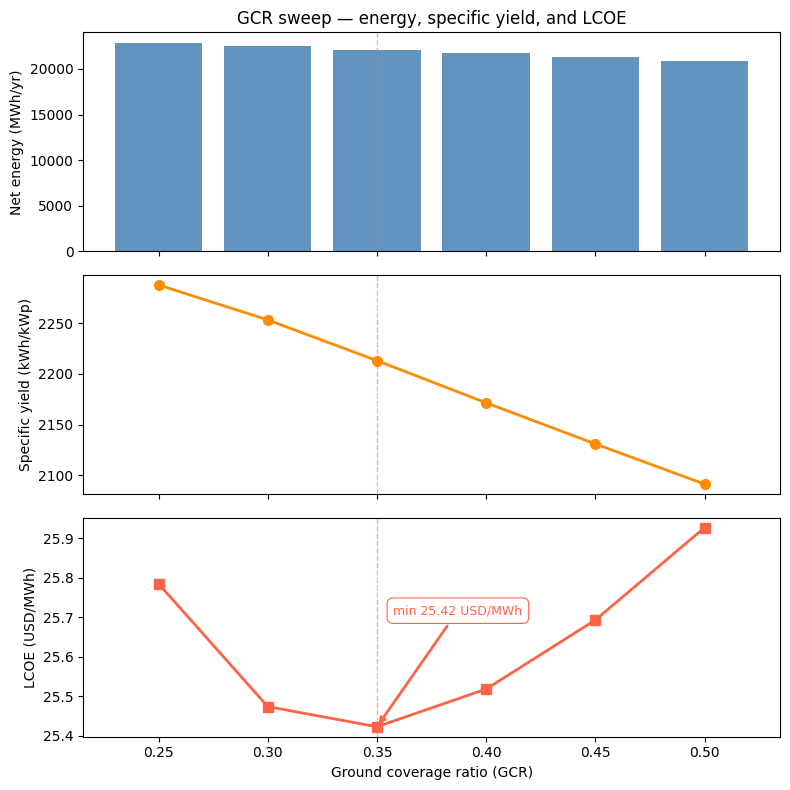

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

gcr_labels = sweep_df['gcr'].apply(lambda x: f"{x:.2f}")
opt_label  = f"{optimal_lcoe['gcr']:.2f}"
opt_idx    = list(gcr_labels).index(opt_label)
opt_lcoe   = optimal_lcoe['lcoe_usd_per_mwh']

ax1.bar(gcr_labels, sweep_df['net_energy_MWh'], color='steelblue', alpha=0.85)
ax1.set_ylabel('Net energy (MWh/yr)')
ax1.set_ylim(bottom=0)
ax1.set_title('GCR sweep — energy, specific yield, and LCOE')

ax2.plot(gcr_labels, sweep_df['specific_yield_kWh_kWp'],
         'o-', color='darkorange', linewidth=2, markersize=7)
ax2.set_ylabel('Specific yield (kWh/kWp)')

ax3.plot(gcr_labels, sweep_df['lcoe_usd_per_mwh'],
         's-', color='tomato', linewidth=2, markersize=7)
ax3.set_ylabel('LCOE (USD/MWh)')
ax3.set_xlabel('Ground coverage ratio (GCR)')

# Annotate optimal LCOE — box anchored at its left edge so it sits to the right of the line
lcoe_range = sweep_df['lcoe_usd_per_mwh'].max() - sweep_df['lcoe_usd_per_mwh'].min()
ax3.annotate(
    f"min {opt_lcoe:.2f} USD/MWh",
    xy=(opt_idx, opt_lcoe),
    xytext=(opt_idx + 0.15, opt_lcoe + lcoe_range * 0.55),
    fontsize=9, color='tomato', ha='left', va='bottom',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='tomato', lw=0.8),
    arrowprops=dict(arrowstyle='->', color='tomato', lw=2.0),
)

# Dashed vertical line at LCOE optimum on all panels
for ax in (ax1, ax2, ax3):
    ax.axvline(opt_idx, color='tomato', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 12. Summary

You have completed a full API-driven energy yield assessment using the SolarFarmer Python SDK:

| Step | Tool / Method |
|------|---------------|
| Fetch TMY weather | `solcast.tmy.radiation_and_weather()` |
| Convert to SolarFarmer format | `sf.from_solcast(df, output_path)` |
| Design plant | `PVSystem(...)` — capacity, tilt, GCR, equipment |
| Run calculation | `plant.run_energy_calculation()` |
| Inspect KPIs | `results.get_performance()` |
| Monthly breakdown | `results.get_monthly_results_table()` |
| Loss analysis | `results.print_annual_results()` + waterfall chart |
| GCR + LCOE sweep | `plant.make_copy()` + sweep loop |

---
## Next steps

**What to explore after the workshop:**
- Feed **Solar Resource Compass soiling** (`soiling.monthly_profiles`) and **albedo** (`albedo.monthly_profiles`) directly into `plant.soiling_loss` and `plant.albedo` instead of the hardcoded estimates used here
- Extend the GCR sweep into a **2-D optimisation surface** by also sweeping tilt (tracker max rotation angle)
- Use `plant.to_file()` and `PVSystem.from_file()` to persist and reload designs between sessions
- For full design fidelity, move to **Workflow 3** with `EnergyCalculationInputs` and explicit Pydantic models

**Documentation & support:**  
https://dnv-opensource.github.io/solarfarmer-python-sdk/  
solarfarmer@dnv.com

*Thank you for joining the DNV workshop at PVPMC 2026!*
